# 04 — SIPRI Militarization Pipeline

**Fonte:** SIPRI Military Expenditure Database (1949–2025)  
**Entrada:** `data/intermediate/sipri_country_year_base.csv`  
**Saída:** `data/final/conflict_country_year_sipri.csv`  
**Chave de junção:** `country` + `year` (mesma do dataset base)

---

## Posição no pipeline

```
notebooks/exploration/01_ucdp_country_year_eda.ipynb
notebooks/modeling/01_baseline_models.ipynb          — F1 = 0.8571
notebooks/modeling/02_temporal_features_models.ipynb — F1 = 0.8670
notebooks/modeling/03_prio_persistence_pipeline.ipynb
notebooks/modeling/04_sipri_militarization_pipeline.ipynb  ← ESTE
notebooks/modeling/05_probability_calibration.ipynb
```

## Hipótese causal

Países que **aumentam persistentemente sua despesa militar** relativa ao PIB
estão sinalizando — de forma observável ex ante — percepção de ameaça ou
intenção coercitiva. Essa hipótese opera em três mecanismos:

1. **Preparo institucional**: maiores orçamentos de defesa precedem mobilizações.
2. **Sinalização de força**: corridas armamentistas correlacionam com escalada.
3. **Capacidade residual**: países com gasto volátil (alta std_5y) tendem a
   apresentar instabilidade política que co-ocorre com conflito.

O módulo **não** afirma causalidade direta; afirma que as features de
militarização carregam sinal preditivo independente sobre `target_conflict_next_year`.

## O que este notebook faz

O ETL e o feature engineering são delegados integralmente ao `src/`. Este
notebook se concentra em:

- Análise exploratória das features de militarização;
- Validação da consistência com o target supervisionado;
- Comparação rápida de F1: base vs. base + SIPRI;
- Importância das features SIPRI no modelo;
- Experimentos de ablação por feature.


## 1. Imports e configuração

In [1]:
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

matplotlib.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data.prepare_sipri_dataset import run as prepare_sipri
from features.build_sipri_features import (
    load_intermediate, load_base,
    build_sipri_features, save_dataset,
    SIPRI_FEATURE_COLS, OUTPUT_PATH,
)

## 2. Gerar dataset com features SIPRI

O pipeline completo é executado via dois módulos do `src/`:

- `prepare_sipri_dataset.run()` → ETL bruto → `sipri_country_year_base.csv`
- `build_sipri_features()` → features temporais → `conflict_country_year_sipri.csv`

> **Nota:** Se o arquivo `sipri_country_year_base.csv` já existir (ETL anterior),
> comente a chamada a `prepare_sipri()` para pular o ETL e ir direto ao feature engineering.

In [2]:
# ETL: necessário apenas se o raw SIPRI xlsx estiver disponível.
# Comente esta linha se o intermediate já existir.
# prepare_sipri()

df_enriched, feature_cols = build_sipri_features(load_intermediate(), load_base())

print(f"Shape final      : {df_enriched.shape}")
print(f"Anos cobertos    : {df_enriched['year'].min()} – {df_enriched['year'].max()}")
print(f"Países únicos    : {df_enriched['country'].nunique()}")
print(f"Features SIPRI   : {len(feature_cols)}")
print()
df_enriched[["country", "year"] + feature_cols].head(10)

Shape final      : (6737, 28)
Anos cobertos    : 1989 – 2023
Países únicos    : 199
Features SIPRI   : 6



,country,year,sipri_country_existed,sipri_milex_pct_gdp,sipri_milex_growth_5y,sipri_milex_burden_rolling_3y,sipri_milex_std_5y,sipri_milex_acceleration
0,United States Of America,1989,NaN,NaN,NaN,NaN,NaN,NaN
1,United States Of America,1990,NaN,NaN,NaN,NaN,NaN,NaN
2,United States Of America,1991,NaN,NaN,NaN,NaN,NaN,NaN
3,United States Of America,1992,NaN,NaN,NaN,NaN,NaN,NaN
4,United States Of America,1993,NaN,NaN,NaN,NaN,NaN,NaN
5,United States Of America,1994,NaN,NaN,NaN,NaN,NaN,NaN
6,United States Of America,1995,NaN,NaN,NaN,NaN,NaN,NaN
7,United States Of America,1996,NaN,NaN,NaN,NaN,NaN,NaN
8,United States Of America,1997,NaN,NaN,NaN,NaN,NaN,NaN
9,United States Of America,1998,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Análise exploratória das features de militarização

### 3.1 Distribuição do military burden (% do PIB)

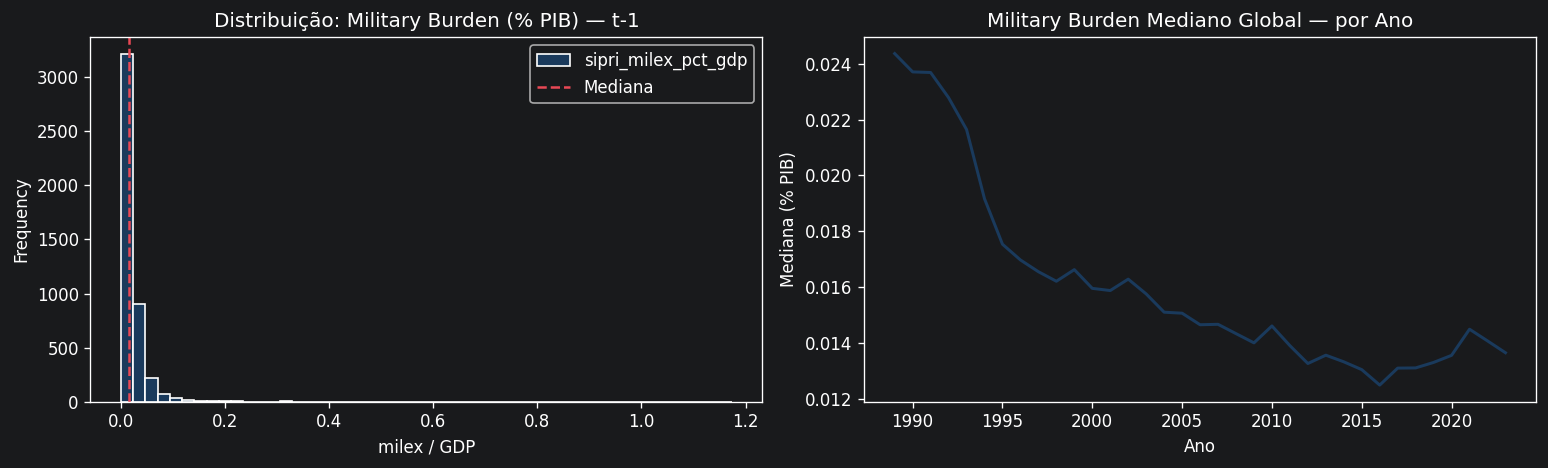

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma do burden
df_enriched["sipri_milex_pct_gdp"].dropna().plot(
    kind="hist", bins=50, ax=axes[0], color="#1A3A5C", edgecolor="white"
)
axes[0].set_title("Distribuição: Military Burden (% PIB) — t-1")
axes[0].set_xlabel("milex / GDP")
axes[0].axvline(df_enriched["sipri_milex_pct_gdp"].median(), color="#E84855",
                linestyle="--", label=f"Mediana")
axes[0].legend()

# Burden ao longo do tempo (global)
(
    df_enriched.groupby("year")["sipri_milex_pct_gdp"]
    .median()
    .plot(ax=axes[1], color="#1A3A5C", linewidth=1.8)
)
axes[1].set_title("Military Burden Mediano Global — por Ano")
axes[1].set_ylabel("Mediana (% PIB)")
axes[1].set_xlabel("Ano")

plt.tight_layout()
plt.show()

### 3.2 Correlação entre features SIPRI

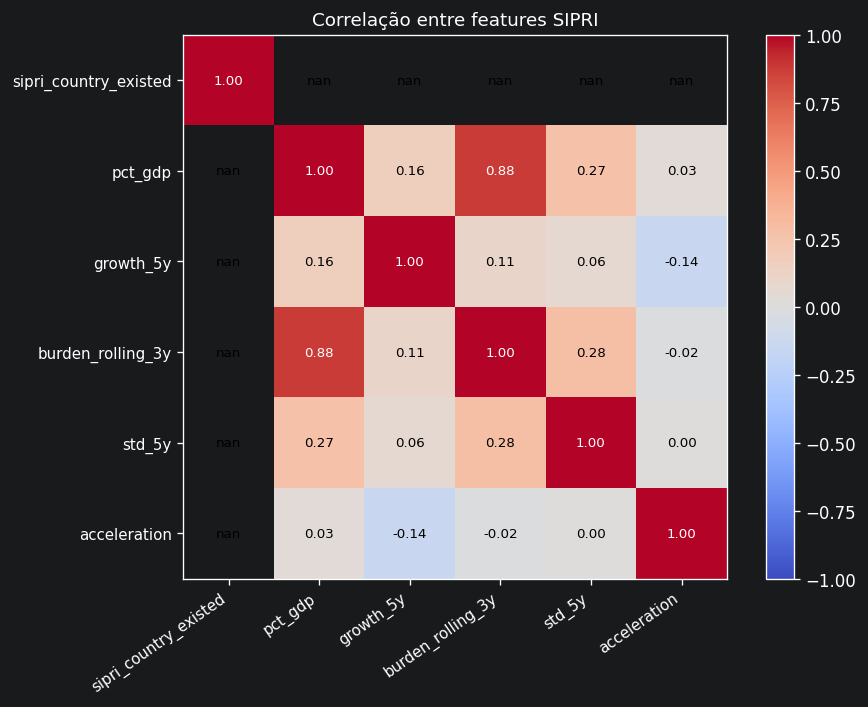

In [4]:
import matplotlib.ticker as mticker

corr = df_enriched[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels([c.replace("sipri_milex_", "") for c in feature_cols],
                   rotation=35, ha="right", fontsize=9)
ax.set_yticklabels([c.replace("sipri_milex_", "") for c in feature_cols], fontsize=9)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")

ax.set_title("Correlação entre features SIPRI", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Validação — consistência com o target

Países com **alto crescimento de gasto militar** devem apresentar
taxa de conflito no ano seguinte sistematicamente diferente dos demais.
Isso valida a hipótese de que as features SIPRI carregam sinal.

In [5]:
TARGET = "target_conflict_next_year"

# Criar flags binárias para validação
df_val = df_enriched.copy()
df_val["high_burden"]   = (df_val["sipri_milex_pct_gdp"] >
                            df_val["sipri_milex_pct_gdp"].median()).astype(float)
df_val["high_growth"]   = (df_val["sipri_milex_growth_5y"] > 0).astype(float)
df_val["high_accel"]    = (df_val["sipri_milex_acceleration"] > 0).astype(float)
df_val["high_vol"]      = (df_val["sipri_milex_std_5y"] >
                            df_val["sipri_milex_std_5y"].median()).astype(float)

checks = [
    ("high_burden", "Burden acima da mediana",   "Burden abaixo da mediana"),
    ("high_growth", "Crescimento 5y positivo",   "Crescimento 5y negativo"),
    ("high_accel",  "Aceleração positiva",        "Desaceleração"),
    ("high_vol",    "Alta volatilidade orçam.",   "Baixa volatilidade"),
]

print("=== Taxa de target por flag SIPRI ===")
for col, label_1, label_0 in checks:
    sub = df_val.dropna(subset=[col, TARGET])
    taxa = (
        sub.groupby(col)[TARGET]
        .mean()
        .rename({0.0: label_0, 1.0: label_1})
        .round(4)
    )
    print(f"\n{col}:")
    print(taxa.to_string())

=== Taxa de target por flag SIPRI ===

high_burden:
high_burden
Burden abaixo da mediana    0.2631
Burden acima da mediana     0.3590

high_growth:
high_growth
Crescimento 5y negativo    0.2642
Crescimento 5y positivo    0.3414

high_accel:
high_accel
Desaceleração          0.2843
Aceleração positiva    0.3183

high_vol:
high_vol
Baixa volatilidade          0.2574
Alta volatilidade orçam.    0.3725


## 5. Comparação rápida de F1

Treino rápido para medir o ganho das features SIPRI sobre o baseline.
Usa o mesmo split temporal e as mesmas features base dos notebooks anteriores.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

TRAIN_END_YEAR = 2016

FEATURE_COLUMNS_BASE = [
    "year",
    "state_based_conflict_exists",
    "state_based_dyad_count",
    "state_based_deaths_best",
    "intrastate_conflict_exists",
    "intrastate_deaths_best",
    "interstate_conflict_exists",
    "interstate_deaths_best",
    "non_state_conflict_exists",
    "non_state_dyad_count",
    "non_state_deaths_best",
    "one_sided_violence_exists",
    "one_sided_dyad_count",
    "one_sided_deaths_best",
    "cumulative_organized_violence_deaths_best",
    "organized_violence_exists",
]
FEATURE_COLUMNS_SIPRI = FEATURE_COLUMNS_BASE + feature_cols

# Remover linhas sem target
df_model = df_enriched.dropna(subset=[TARGET]).copy()

# Imputar NaN nas features SIPRI com 0 (ausência de dado ≠ ausência de gasto)
df_model[feature_cols] = df_model[feature_cols].fillna(0)

train_mask = df_model["year"] <= TRAIN_END_YEAR
test_mask  = df_model["year"] >  TRAIN_END_YEAR

y_train = df_model.loc[train_mask, TARGET]
y_test  = df_model.loc[test_mask,  TARGET]

rf_params = dict(
    n_estimators=300, max_depth=6, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1,
)

# Modelo BASE (referência)
rf_base = RandomForestClassifier(**rf_params)
rf_base.fit(df_model.loc[train_mask, FEATURE_COLUMNS_BASE], y_train)
f1_base = f1_score(
    y_test,
    rf_base.predict(df_model.loc[test_mask, FEATURE_COLUMNS_BASE]),
    zero_division=0,
)

# Modelo BASE + SIPRI
rf_sipri = RandomForestClassifier(**rf_params)
rf_sipri.fit(df_model.loc[train_mask, FEATURE_COLUMNS_SIPRI], y_train)
y_pred_sipri = rf_sipri.predict(df_model.loc[test_mask, FEATURE_COLUMNS_SIPRI])
f1_sipri = f1_score(y_test, y_pred_sipri, zero_division=0)

print("=" * 45)
print(f"  F1 Base (referência) : {f1_base:.4f}")
print(f"  F1 Base + SIPRI      : {f1_sipri:.4f}")
print(f"  Ganho                : {f1_sipri - f1_base:+.4f}")
print("=" * 45)
print()
print("Relatório detalhado (Base + SIPRI):")
print(classification_report(
    y_test, y_pred_sipri,
    target_names=["Sem conflito", "Com conflito"],
    zero_division=0,
))

  F1 Base (referência) : 0.8571
  F1 Base + SIPRI      : 0.8565
  Ganho                : -0.0007

Relatório detalhado (Base + SIPRI):
              precision    recall  f1-score   support

Sem conflito       0.93      0.93      0.93       931
Com conflito       0.86      0.85      0.86       441

    accuracy                           0.91      1372
   macro avg       0.90      0.89      0.89      1372
weighted avg       0.91      0.91      0.91      1372



## 6. Importância das features

Top 20 features por importância:
organized_violence_exists                    0.2243
cumulative_organized_violence_deaths_best    0.2056
intrastate_deaths_best                       0.0813
intrastate_conflict_exists                   0.0779
one_sided_dyad_count                         0.0662
state_based_dyad_count                       0.0588
one_sided_violence_exists                    0.0570
state_based_deaths_best                      0.0541
state_based_conflict_exists                  0.0520
one_sided_deaths_best                        0.0320
non_state_dyad_count                         0.0182
non_state_conflict_exists                    0.0181
non_state_deaths_best                        0.0159
sipri_milex_std_5y                           0.0091
sipri_milex_acceleration                     0.0063
sipri_milex_burden_rolling_3y                0.0059
sipri_milex_growth_5y                        0.0056
sipri_milex_pct_gdp                          0.0055
year                           

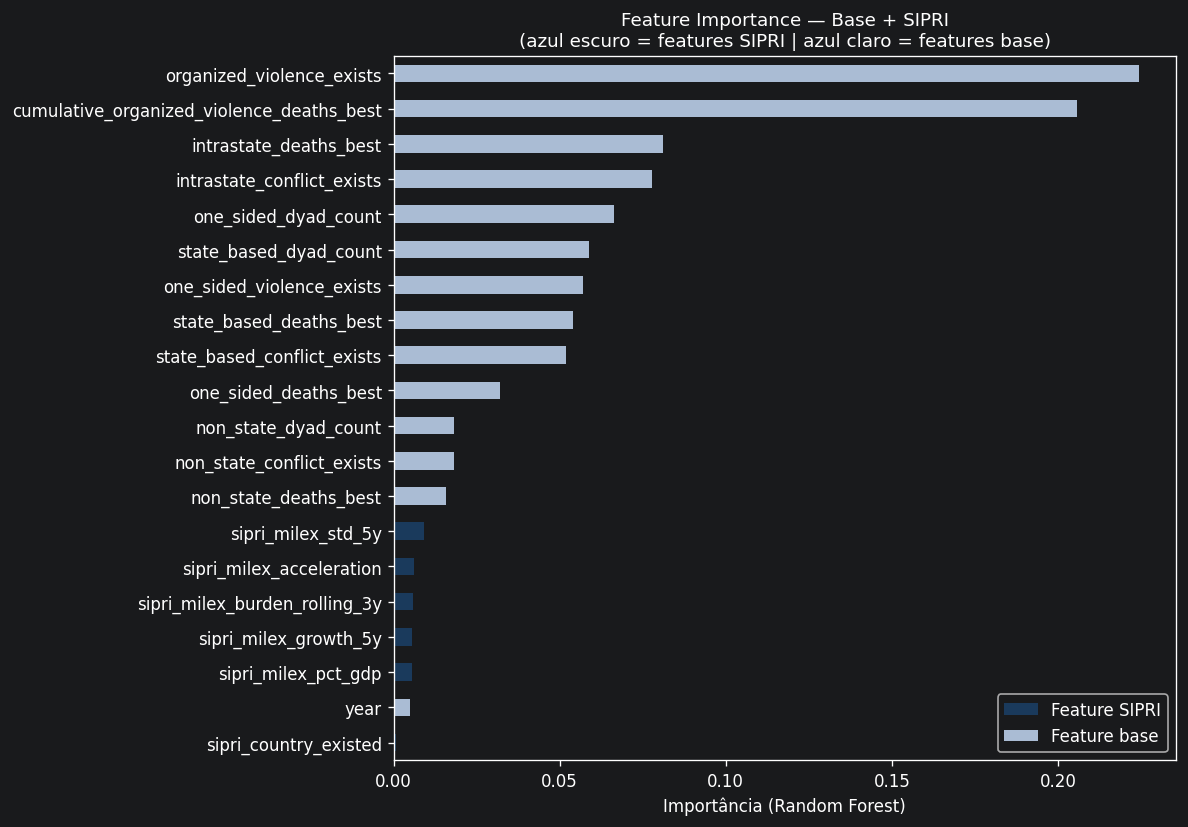

Gráfico salvo em: C:\Users\Leonardo\Desktop\Codigo\Git Enzo\international-conflict-risk-ml\outputs\charts\sipri_feature_importance.png


In [7]:
importances = (
    pd.Series(rf_sipri.feature_importances_, index=FEATURE_COLUMNS_SIPRI)
    .sort_values(ascending=False)
)

print("Top 20 features por importância:")
print(importances.head(20).round(4).to_string())
print()
print("Features SIPRI no top 20:")
for f in importances.head(20).index:
    if f in feature_cols:
        print(f"  ★ {f:<38} {importances[f]:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
cores = [
    "#1A3A5C" if f in feature_cols else "#AABCD4"
    for f in importances.head(20).sort_values().index
]
importances.head(20).sort_values().plot(kind="barh", ax=ax, color=cores)
ax.set_title(
    "Feature Importance — Base + SIPRI\n"
    "(azul escuro = features SIPRI | azul claro = features base)",
    fontsize=11,
)
ax.set_xlabel("Importância (Random Forest)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1A3A5C", label="Feature SIPRI"),
    Patch(facecolor="#AABCD4", label="Feature base"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()

chart_path = PROJECT_ROOT / "outputs" / "charts" / "sipri_feature_importance.png"
chart_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {chart_path}")

## 7. Experimento de ablação por feature SIPRI

Mede o impacto individual de cada feature SIPRI ao removê-la do conjunto.

In [8]:
ablation_results = []

for remove_col in feature_cols:
    cols_subset = [c for c in FEATURE_COLUMNS_SIPRI if c != remove_col]
    rf_abl = RandomForestClassifier(**rf_params)
    rf_abl.fit(df_model.loc[train_mask, cols_subset], y_train)
    f1_abl = f1_score(
        y_test,
        rf_abl.predict(df_model.loc[test_mask, cols_subset]),
        zero_division=0,
    )
    ablation_results.append({
        "removed_feature": remove_col,
        "f1_without"     : round(f1_abl, 4),
        "f1_full"        : round(f1_sipri, 4),
        "delta"          : round(f1_abl - f1_sipri, 4),
    })

df_abl = pd.DataFrame(ablation_results).sort_values("delta")
print("Ablação por feature SIPRI (delta = F1 sem feature − F1 completo):")
print(df_abl.to_string(index=False))
print()
print("Interpretação:")
print("  delta < 0 → feature contribui positivamente (remover piora o modelo)")
print("  delta > 0 → feature adiciona ruído (remover melhora o modelo)")

Ablação por feature SIPRI (delta = F1 sem feature − F1 completo):
              removed_feature  f1_without  f1_full   delta
        sipri_country_existed      0.8552   0.8565 -0.0013
sipri_milex_burden_rolling_3y      0.8552   0.8565 -0.0013
     sipri_milex_acceleration      0.8552   0.8565 -0.0013
           sipri_milex_std_5y      0.8552   0.8565 -0.0013
        sipri_milex_growth_5y      0.8565   0.8565  0.0000
          sipri_milex_pct_gdp      0.8565   0.8565  0.0000

Interpretação:
  delta < 0 → feature contribui positivamente (remover piora o modelo)
  delta > 0 → feature adiciona ruído (remover melhora o modelo)


## 8. Salvar dataset enriquecido

Delega para `save_dataset()` de `src/features/build_sipri_features.py`,
mantendo o mesmo padrão de todos os outros pipelines do projeto.

In [9]:
save_dataset(df_enriched)

print(f"Arquivo salvo : {OUTPUT_PATH}")
print(f"Shape final   : {df_enriched.shape}")
print()
print("Próximo passo:")
print("  notebooks/modeling/05_probability_calibration.ipynb")
print("  src/models/train_conflict_risk_model.py (após integração SIPRI)")

Arquivo salvo : C:\Users\Leonardo\Desktop\Codigo\Git Enzo\international-conflict-risk-ml\data\final\conflict_country_year_sipri.csv
Shape final   : (6737, 28)

Próximo passo:
  notebooks/modeling/05_probability_calibration.ipynb
  src/models/train_conflict_risk_model.py (após integração SIPRI)
